In [ ]:
!pip install numpyro

In [ ]:
import pandas as pd
import numpy as np
import jax
import jax.numpy as jnp
from jax import random
import matplotlib.pyplot as plt
import arviz as az

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error

In [ ]:
import numpyro
import numpyro.distributions as dist
from numpyro.infer import MCMC, NUTS
from numpyro.infer import SVI, Trace_ELBO, autoguide
from numpyro.infer import Predictive
from numpyro.optim import Adam

#Concrete Dataset

The Concrete Compressive Strength dataset contains 1030 observations over 9 variables.'Concrete compression strenght' is the target variable. The 8 predictors define the specific concrete mixture, by providing the volume of the ingredients, like 'Cement', 'Fly Ash' or 'Superplasticizer', together with the 'Age' of the compound. The 'Age' is in days and goes from 1 to 365.

There are no missing values.

In [ ]:
df = pd.read_excel("Concrete_Data.xls")

In [ ]:
#Changing variable names to make them more readable
new_names = [
    'Cement',
    'Blast Furnace Slag',
    'Fly Ash',
    'Water',
    'Superplasticizer',
    'Coarse Aggregate',
    'Fine Aggregate',
    'Age',
    'Compressive Strength'
]

df.columns = new_names

print("The dataset contains 9 variables, with the target being 'Concrete compression strenght:'\n")
print(df.columns.values)

The dataset contains 9 variables, with the target being 'Concrete compression strenght:'

['Cement' 'Blast Furnace Slag' 'Fly Ash' 'Water' 'Superplasticizer'
 'Coarse Aggregate' 'Fine Aggregate' 'Age' 'Compressive Strength']


In [ ]:
print(df.head())

   Cement  Blast Furnace Slag  Fly Ash  Water  Superplasticizer  \
0   540.0                 0.0      0.0  162.0               2.5   
1   540.0                 0.0      0.0  162.0               2.5   
2   332.5               142.5      0.0  228.0               0.0   
3   332.5               142.5      0.0  228.0               0.0   
4   198.6               132.4      0.0  192.0               0.0   

   Coarse Aggregate  Fine Aggregate  Age  Compressive Strength  
0            1040.0           676.0   28             79.986111  
1            1055.0           676.0   28             61.887366  
2             932.0           594.0  270             40.269535  
3             932.0           594.0  365             41.052780  
4             978.4           825.5  360             44.296075  


The average Compressive Strenght is about 35.8 MPa, with a minimum of 2.3 MPa and a maximum of 82.6 MPa. These values will become important when comparing the RMSE of the network.

In [ ]:
print("The target is characterized by the following statistics:")
print("max:", max(df['Compressive Strength']))
print("min:", min(df['Compressive Strength']))
print("mean:", np.mean(df['Compressive Strength']))

The target is characterized by the following statistics:
max: 82.5992248
min: 2.331807832
mean: 35.8178358261136


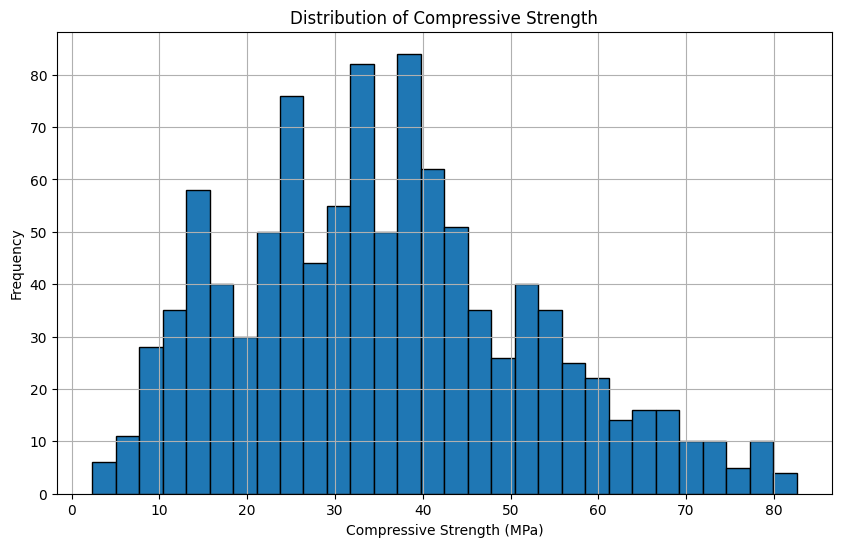

In [ ]:
plt.figure(figsize=(10, 6))
plt.hist(df['Compressive Strength'], bins=30, edgecolor='black')
plt.title('Distribution of Compressive Strength')
plt.xlabel('Compressive Strength (MPa)')
plt.ylabel('Frequency')
plt.grid(True)
plt.show()

In [ ]:
print("There are no missing values, as also specified on the dataset page:")
print(df.isnull().sum())

There are no missing values, as also specified on the dataset page:
Cement                  0
Blast Furnace Slag      0
Fly Ash                 0
Water                   0
Superplasticizer        0
Coarse Aggregate        0
Fine Aggregate          0
Age                     0
Compressive Strength    0
dtype: int64


Neural Networks in general, and Bayesian NN even more so, can be sensible to the data scale. We intend to use for the MCMC a weakly informative gaussian prior, which assumes some plausible range for the model weights and biases. Standardizing the data is usually an important pre-processing step in these cases.

In [ ]:
X = df.iloc[:, :-1].values #Predittori
y = df.iloc[:, -1].values.reshape(-1, 1) #Target

scaler_x = StandardScaler()
scaler_y = StandardScaler()
X_scaled = scaler_x.fit_transform(X) #Standardizzazione
y_scaled = scaler_y.fit_transform(y)

X_train, X_test, y_train, y_test = train_test_split(X_scaled, y_scaled, test_size=0.2, random_state=42)

#To make use of numpyro, we need to transform the train data into jax arrays
X_train_jax = jnp.array(X_train)
y_train_jax = jnp.array(y_train).flatten()

#Bayesian Network

To implement a Bayesian Neural Network, we can take advantage of the numpyro library, which allows for a more straigh-forward definition of neural networks with random weights and biases. In this case, we use 2 hidden layers and a separate learnable parameter for the standard deviation. The 2 hidden layers have 16 and 8 parameters respectively. We want to keep the number of parameters down as we already will need to make many estimations for each and don't want the model to be too slow. Also, too many parameters for an 8-feature, 1030-observations dataset may produce an overfitting model.

The two hidden layers are passed through a ReLu activation function, and the final output is the weighted sum, representing the mean of the normal we use to model the likelihood. The variance parameter is adjusted by the network in the direction of maximizing the likelihood. We use a single variance parameter, obtaining a homoschedastic model of the data given the parameters. More complex approach could make use of a variable sigma which would be adjusted, as the mean already is, for every input.

In [ ]:
def model(X, y=None):
    prior_std = 1.0 #We initialize the priors STD to 1

    n_features = X.shape[1]
    n_hidden1 = 16
    n_hidden2 = 8

    #Hidden layers
    w1 = numpyro.sample("w1", dist.Normal(jnp.zeros((n_features, n_hidden1)), prior_std))
    b1 = numpyro.sample("b1", dist.Normal(jnp.zeros(n_hidden1), prior_std))
    z1 = jax.nn.relu(jnp.dot(X, w1) + b1)

    w2 = numpyro.sample("w2", dist.Normal(jnp.zeros((n_hidden1, n_hidden2)), prior_std))
    b2 = numpyro.sample("b2", dist.Normal(jnp.zeros(n_hidden2), prior_std))
    z2 = jax.nn.relu(jnp.dot(z1, w2) + b2)

    #Output
    w3 = numpyro.sample("w3", dist.Normal(jnp.zeros((n_hidden2, 1)), prior_std))
    b3 = numpyro.sample("b3", dist.Normal(jnp.zeros(1), prior_std))
    mu = jnp.dot(z2, w3) + b3

    #Learnable parameter sigma for the variance. Halfnorma so sigma>0
    sigma = numpyro.sample("sigma", dist.HalfNormal(1.0))

    #Likelihood
    #The .plate method manages the 1030 observations as independent vector
    #The .sample method, when obs is passed, checks the fitted normal against
    #the actual data distributions and calculates the likelihood, either for
    #training or for prediction.
    with numpyro.plate("data", X.shape[0]):
        numpyro.sample("obs", dist.Normal(mu.flatten(), sigma), obs=y)

#Markov Chain Monte Carlo BNN

A Markov Chain Monte Carlo is an approach to solving Bayes inference through a sampling process of the posterior.

$$p(θ|D) = \frac{p(θ)p(D|θ)}{p(D)} = \frac{p(θ)p(D|θ)}{∫p(D|θ)p(θ)dθ}$$

Once we have assumed a certain prior $p(\theta)$ (for example a normal distribution) and defined a parametric likelihood, the numerator can be solved without much computational expense (it is a point estimate). The problems come from the denumerator, which can be very complex to calculate, especially if we want to compute the weights of large Bayesian Neural Networks with it.

One way to solve the problem is MCMC, which doesn't offer an explicit formulation for the posterior but allows us to calculate it's mean and variance by calculating many samples (if necessary, even millions or more) from it. The process takes advantage of the fact we know the functional form of the numerator and can sample from this function following a Monte Carlo process. However, this MC is also aided by a Markov Chain search process which makes the estimation much more efficient and reliable. The specifics of how the sampling process is solved is the basis for many different ways in which MCMC can be implemented.

We use the NUTS sampler, which stands for No U-Turns Sampler. It is an improved version of the Hamiltonian Monte-Carlo. HMC explores the parameter space treating it as an energy surface and searching its minimum, in a parallel with physical computations. The NUTS sampler tries to select the correct distance each path should cover before stopping to guarantee an efficient exploration of the space by stopping when it detects a "u-turn" in the path, that is when the parameter trajectory seems to be going toward the state from which it started.

The num_warmup and num_samples are the fundamental parameters in this case, as they define the number of samples to be considered part of the burn-in phase and those that we actually consider a good approximate sampling from the posterior distribution. num_chains defines the number of chains to use. On simpler datasets, even 1 may be enough. We use 2.

Training Time: about 15 minutes.

In [ ]:
#Key for reproducibility
rng_key = random.PRNGKey(0)
rng_key, rng_key_predict = random.split(rng_key)

nuts_kernel = NUTS(model) #Passing the defined model to NUTS

#MCMC through NUTS
mcmc = MCMC(
    nuts_kernel,
    num_samples=1000,    #Good samples
    num_warmup=1000,      #Burn-in samples
    num_chains=2        #Number of chains
)

mcmc.run(rng_key, X_train_jax, y_train_jax)

/tmp/ipykernel_12398/4282559508.py:8: UserWarning: There are not enough devices to run parallel chains: expected 2 but got 1. Chains will be drawn sequentially. If you are running MCMC in CPU, consider using `numpyro.set_host_device_count(2)` at the beginning of your program. You can double-check how many devices are available in your system using `jax.local_device_count()`.
  mcmc = MCMC(
sample: 100%|██████████| 2000/2000 [07:41<00:00,  4.33it/s, 1023 steps of size 1.17e-03. acc. prob=0.87]


After having trained the network and defined the weights distributions, we can check the model quality on the test set. Since we have a distribution for each weight, made up by 1000 estimates each (num_samples = 1000), we can pass each input through all these different network iterations and get 1000 estimates for the concrete compression strenght (in MPa) from each sample. We can then calculate the mean and the variance of each.

In [ ]:
predictive = Predictive(model, posterior_samples=mcmc.get_samples())

rng_key, rng_key_predict = random.split(rng_key)
predictions = predictive(rng_key_predict, X=jnp.array(X_test))

y_pred_samples = predictions['obs']

In [ ]:
y_pred_mean = jnp.mean(y_pred_samples, axis=0) #Mean
y_pred_std = jnp.std(y_pred_samples, axis=0) #STD

#95% Confidence intervals
lower_b = jnp.percentile(y_pred_samples, 2.5, axis=0)
upper_b = jnp.percentile(y_pred_samples, 97.5, axis=0)

#Inverting the scale back to the original
y_pred_mean_mpa = scaler_y.inverse_transform(y_pred_mean.reshape(-1, 1))
y_test_mpa = scaler_y.inverse_transform(y_test.reshape(-1, 1))

A plot of observed vs fitted on 50 samples from the test set shows that the model is doing a moderately good job. Most observations are in the expected CI, with some of the fitted value being very close to the actual values. However, there are still some observed values which fall outside the confidence intervals. The coverage performance is over 92%, which again is a positive result, close to the expected 95%. The Root Mean Square Error is 4.48MPa.

In [ ]:
rmse = np.sqrt(mean_squared_error(y_test_mpa, y_pred_mean_mpa))
print(f"RMSE: {rmse:.2f} MPa")
average_pred_std_mpa = np.mean(y_pred_std)*scaler_y.scale_
print(f"Average Predictive Std Dev: {average_pred_std_mpa.item():.2f} MPa")

RMSE: 4.48 MPa
Average Predictive Std Dev: 3.57 MPa


In [ ]:
is_inside = (y_test.flatten() >= lower_b) & (y_test.flatten() <= upper_b)
coverage = np.mean(is_inside) * 100

print(f"Coverage Probability (95% CI): {coverage:.2f}%")
print(f"Test set size: {len(y_test)}")
print(f"Correct predictions: {np.sum(is_inside)}")

Coverage Probability (95% CI): 92.23%
Test set size: 206
Correct predictions: 190


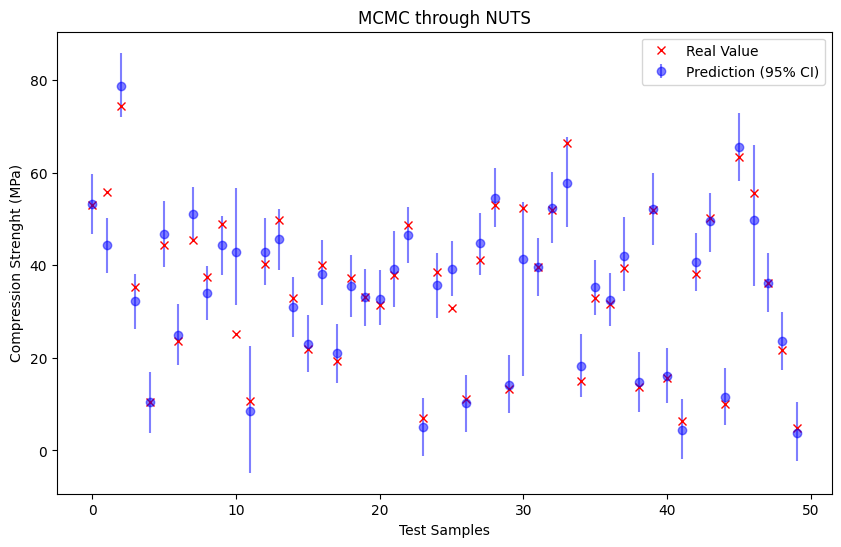

In [ ]:
plt.figure(figsize=(10, 6))

lower_error_distance = (y_pred_mean[:50] - lower_b[:50]) * scaler_y.scale_
upper_error_distance = (upper_b[:50] - y_pred_mean[:50]) * scaler_y.scale_

yerr_asymmetric = [lower_error_distance, upper_error_distance]

plt.errorbar(range(50), y_pred_mean_mpa[:50].flatten(), #50 samples
             yerr=yerr_asymmetric,
             fmt='o', color='blue', alpha=0.5, label='Prediction (95% CI)')
plt.plot(range(50), y_test_mpa[:50].flatten(), 'rx', label='Real Value')
plt.xlabel("Test Samples")
plt.ylabel("Compression Strenght (MPa)")
plt.legend()
plt.title("MCMC through NUTS")
plt.show()

Even if the model showed good precision, a trace plot shows that, while sigma seems to have been appropriately modeled, the parameters (from the output layer for clarity) have been more difficult to fit. The two chains used show parameters distribution quite far from each other and the values of some parameters show an unsatisfactory trend (through the 1000 samples), as some oscillate too strongly.

Also, the R-Hat and ESS values of many parameters are respectively too high (> 1.1) or too low (< 100).

Sometimes, in practical settings, one would still considers this a success and, while we have some mathematical instability, the model does seem able to offer mostly correct predictions about the concrete strenght.

In [ ]:
#mcmc.print_summary()

array([[<Axes: title={'center': 'sigma'}>,
        <Axes: title={'center': 'sigma'}>],
       [<Axes: title={'center': 'w3'}>, <Axes: title={'center': 'w3'}>]],
      dtype=object)

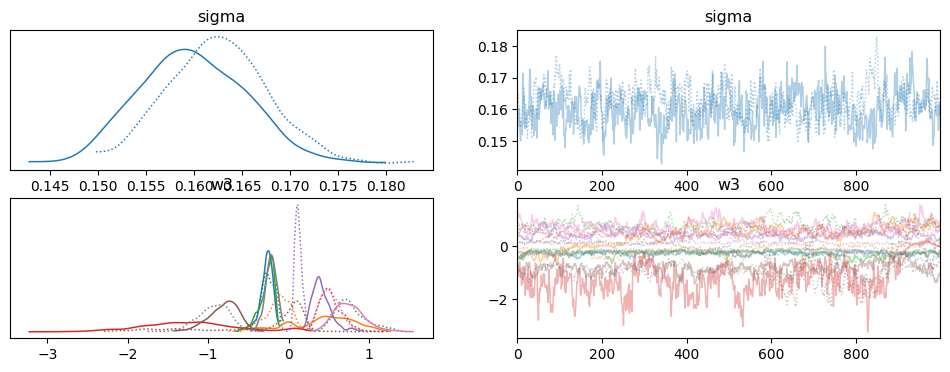

In [ ]:
idata = az.from_numpyro(mcmc)

#Trace Plot
az.plot_trace(idata, var_names=["sigma", "w3"])

In [ ]:
summary_df = az.summary(idata)

#Defining r-hat and ess thresholds
rhat_threshold = 1.05
ess_threshold = 100

bad_rhat = summary_df[summary_df['r_hat'] > rhat_threshold]
bad_ess_bulk = summary_df[summary_df['ess_bulk'] < ess_threshold]
bad_ess_tail = summary_df[summary_df['ess_tail'] < ess_threshold]

print(f"Number of parameters: {len(summary_df)}")
print(f"Parameters with a bad R-hat (> {rhat_threshold}): {len(bad_rhat)}")

"""ESS = Effective Sample Size. Bulk focuses on the bulk (95%) of the distr.
Tail focuses on the tails (5%) of the distributions. If the bulk ESS is a good
value, usually we can say that the point estimate is likely close to the real,
while if the tail ESS is a good value, we can usually say that the variance of
that parameter is likely well estimated."""

print(f"Parameters with a bad ESS Bulk (< {ess_threshold}): {len(bad_ess_bulk)}")
print(f"Parameters with a bad ESS Tail (< {ess_threshold}): {len(bad_ess_tail)}")

Number of parameters: 290
Parameters with a bad R-hat (> 1.05): 272
Parameters with a bad ESS Bulk (< 100): 283
Parameters with a bad ESS Tail (< 100): 235


#Stochastic Variational Inference

The MCMC family of techniques approaches the problem of the Bayes inference by sampling the posterior with Monte Carlo based methods. Another modern, common approach to Bayes inference is Variational Inference (VI). VI doesn't try to sample the "actual" posterior distribution. Instead, it tries to approximate $p(θ|D)$ through a different parametrized probability distribution $q(θ)$. The distance between the two distributions is expressed in terms of the Kullback-Leibler Divergence:

$$ KL(q(θ)||p(θ|D) = E_q\left[log\left(\frac{q(θ)}{p(θ|D)}\right)\right] =
∫_θ q(θ)log\left(\frac{q(θ)}{p(θ|D)}\right)dθ$$

We can't however directly calculate it, as we would need to know the posterior which we actually are trying to approximate. We can instead rely on the following trick:

$$∫_θ q(θ)log\left(\frac{q(θ)}{p(θ|D)}\right)dθ = ∫_θ q(θ)log\left(\frac{q(θ)}{\frac{p(θ)p(D|θ)}{p(D)}}\right)dθ = ∫_θ q(θ)log\left(\frac{q(θ)}{p(θ)p(D|θ)}\right)dθ + log(p(D)) = -ELBO(q(θ)) + log(p(D))$$

Which means that

$$log(p(D)) = KL(q(θ)||p(θ|D)) + ELBO(q(θ))$$

If the divergence is zero, then the log-evidence equals the ELBO, otherwise it is bigger. This justifies the name ELBO which stands for Evidence Lower Bound. We cannot calculate the KL divergence, but we can calculate the ELBO and maximizing it means minimizing KL. Therefore, we can approximate the posterior by modifying the parameters in such a way that the ELBO of the approximate $q(θ)$ distribution becomes bigger and bigger.

There are many different ways of actually implementing VI. Here we use Stochastic Variance Inference (SVI), which is an implementation of Automatic Differentiation Variational Inference together with a mini-batch based gradient descent optimization.

Training Time: about 1 minute.

In [ ]:
#The guide is the approximating distribution q. AutoNormal assumes the parameters
#can be modeled as independent normal distributions, each with its own mean and variance
guide = autoguide.AutoNormal(model)
optimizer = Adam(step_size=0.01)

#Trace_ELBO is the negative of the ELBO, which we use as the loss function
svi = SVI(model, guide, optimizer, loss=Trace_ELBO())

In [ ]:
svi_state = svi.init(random.PRNGKey(1), X_train_jax, y_train_jax)

elbo_history = []
num_steps = 2000

for i in range(num_steps):
    svi_state, loss = svi.update(svi_state, X_train_jax, y_train_jax)
    elbo_history.append(loss)

    if i % 100 == 0:
        print(f"Step {i} - Loss (Negative ELBO): {loss:.4f}")

params = svi.get_params(svi_state)

Step 0 - Loss (Negative ELBO): 67917.6484
Step 100 - Loss (Negative ELBO): 2961.2471
Step 200 - Loss (Negative ELBO): 2398.5798
Step 300 - Loss (Negative ELBO): 2309.6985
Step 400 - Loss (Negative ELBO): 2192.2490
Step 500 - Loss (Negative ELBO): 2102.0076
Step 600 - Loss (Negative ELBO): 2024.3730
Step 700 - Loss (Negative ELBO): 1885.0701
Step 800 - Loss (Negative ELBO): 1927.1387
Step 900 - Loss (Negative ELBO): 1741.0044
Step 1000 - Loss (Negative ELBO): 1661.2039
Step 1100 - Loss (Negative ELBO): 1604.6326
Step 1200 - Loss (Negative ELBO): 1508.0562
Step 1300 - Loss (Negative ELBO): 1426.4318
Step 1400 - Loss (Negative ELBO): 1318.0046
Step 1500 - Loss (Negative ELBO): 1320.7830
Step 1600 - Loss (Negative ELBO): 1291.1764
Step 1700 - Loss (Negative ELBO): 1222.7971
Step 1800 - Loss (Negative ELBO): 1213.1626
Step 1900 - Loss (Negative ELBO): 1116.4930


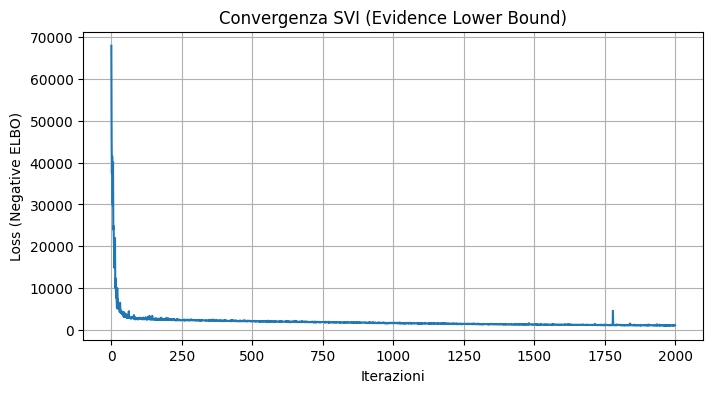

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 4))
plt.plot(elbo_history)
plt.title("Convergenza SVI (Evidence Lower Bound)")
plt.xlabel("Iterazioni")
plt.ylabel("Loss (Negative ELBO)")
plt.grid(True)
plt.show()

As before, SVI has allowed us to learn the distribution of each weight and bias in the neural network. We can now take those distributions and use them to output a manually selected number of estimates for each input from the test set. In continuity with the MCMC, we estimate 1000 values for each input and then calculate their mean and std dev.

In [ ]:
#Dopo aver ottenuto la nostra approssimazione, possiamo usarla per ottenere,
#similmente a prima, 1000 stime per ogni input del test set
predictive_svi = Predictive(model, guide=guide, params=params, num_samples=1000)
svi_samples = predictive_svi(random.PRNGKey(2), X=jnp.array(X_test)) #(1000, 206)

In [ ]:
#print(svi_samples['obs'][0])

In [ ]:
y_pred_mean_VI = jnp.mean(svi_samples['obs'], axis=0) #(206,)
y_pred_std_VI = jnp.std(svi_samples['obs'], axis=0) # La STD delle 1000 previsioni per ciascun campione di test

#95% Confidence intervals, calcolati sui campioni raw per ogni osservazione
lower_b_VI = jnp.percentile(svi_samples['obs'], 2.5, axis=0)
upper_b_VI = jnp.percentile(svi_samples['obs'], 97.5, axis=0)

#Inverting the scale back to the original
y_pred_mean_mpa_VI = scaler_y.inverse_transform(y_pred_mean_VI.reshape(-1, 1))
y_test_mpa = scaler_y.inverse_transform(y_test.reshape(-1, 1))

In [ ]:
rmse_VI = np.sqrt(mean_squared_error(y_test_mpa, y_pred_mean_mpa_VI))
print(f"RMSE: {rmse_VI:.2f} MPa")

average_pred_std_VI_mpa = np.mean(y_pred_std_VI) * scaler_y.scale_
print(f"Average Predictive Std Dev: {average_pred_std_VI_mpa.item():.2f} MPa")

RMSE: 8.83 MPa
Average Predictive Std Dev: 12.29 MPa


In [ ]:
is_inside_VI = (y_test.flatten() >= lower_b_VI) & (y_test.flatten() <= upper_b_VI)
coverage_VI = np.mean(is_inside_VI)*100

print(f"Coverage Probability (95% CI): {coverage_VI:.2f}%")
print(f"Test set size: {len(y_test)}")
print(f"Correct predictions: {np.sum(is_inside_VI)}")

Coverage Probability (95% CI): 100.00%
Test set size: 206
Correct predictions: 206


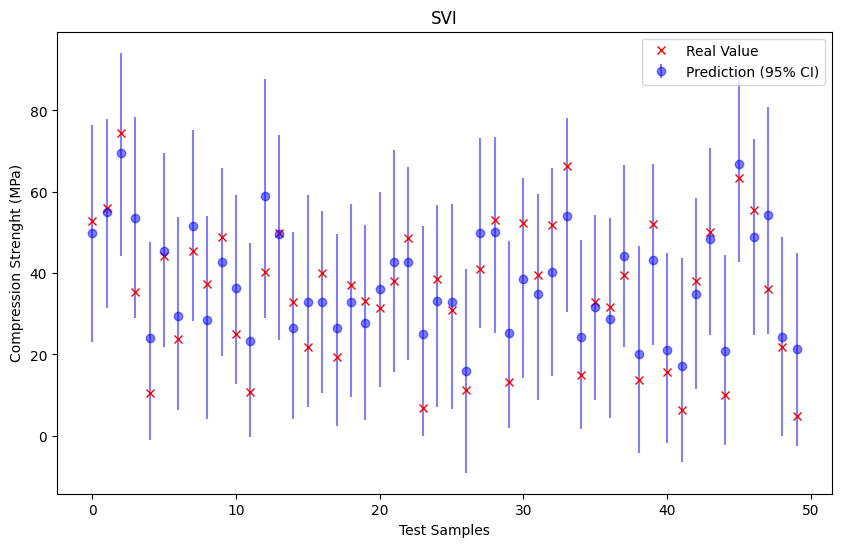

In [ ]:
plt.figure(figsize=(10, 6))

lower_error_distance_VI = (y_pred_mean_VI[:50] - lower_b_VI[:50])*scaler_y.scale_
upper_error_distance_VI = (upper_b_VI[:50] - y_pred_mean_VI[:50])*scaler_y.scale_

yerr_asymmetric_VI = [lower_error_distance_VI, upper_error_distance_VI]

plt.errorbar(range(50), y_pred_mean_mpa_VI[:50].flatten(), #50 samples
             yerr=yerr_asymmetric_VI,
             fmt='o', color='blue', alpha=0.5, label='Prediction (95% CI)')
plt.plot(range(50), y_test_mpa[:50].flatten(), 'rx', label='Real Value')
plt.xlabel("Test Samples")
plt.ylabel("Compression Strenght (MPa)")
plt.legend()
plt.title("SVI")
plt.show()

#Conclusions

The same bayesian neural network, with 2 hidden layers of 16 and 8 neurons respectively (ReLu-activated), showed rather different performances. We tried two configurations, 100 burn-in samples and 100 saved samples for the MCMC against 200 ELBO optimizations steps for the SVI (Case A), as well as 1000 burn-in samples and 1000 saved samples against 2000 optimization steps (Case B).

**Case A**:
The Markov Chain Monte Carlo training, with the No U-Turn Sampler, shows good coverage probability (about 92%) and a low RMSE of about 5 MPa. This is a quite nice results considering the reduced number of samples. However, the trace plots shows two very different sigma distributions and an unstable trend. The third-layer variables show similar results. Training time is about 2 minutes.

The SVI shows much worse performance when trained for 200 optimization steps. The training is fast, about 1 minute, but the RMSE is nearly 30MPa, which means the predicted compression strenghts are very far from the real ones. The coverage probability is 100%, but this isn't a sign of the goodness of the model. Instaed, this is the sign that the confidence intervals have become so big to include every output even with an average error close to 30 MPa.

**Case B**:
By increasing the samples, we get nice results for sigma,  but not all parameters distribution are very close and not all trends very stable yet again. The coverage probability and RMSE are slightly improved, at about 92% and 4 RMSE. The standard deviation of the output distribution is quite similar to the RMSE as well, suggesting the model is estimating it's uncertainty quite well. The training time is about 14 minutes.

After 2000 iterations, the SVI RMSE is evidently improved to about 9 MPa, with a coverage probability again at 100% and large confidence intervals. The output variance is higher than the RMSE at about 12MPa, showing the model overestimates the uncertainty. The training time is about 11 minutes.

**Conclusions:**
The results show something which is generally expected when comparing VI to MCMC, and that is a much higher variance for the variational method. In such small datasets, MCMC is the preferred choice, and offers a much more usable if unstable model even using only 200 total samples. In many high-dimensional cases however, SVI is the only feasible method, thanks to its efficiency. This difference would be much more evident on a bigger dataset.